In [179]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [180]:
data = np.loadtxt('lr_dataset.csv', delimiter= ',')
x_total = data[:,[0,1]]
y_total = data[:,2]
print(x_total.shape[0])

1000


Text(0, 0.5, 'x2')

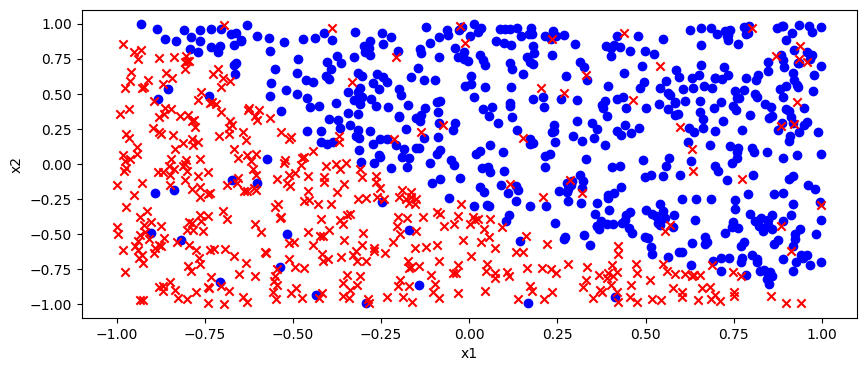

In [181]:
pos_index = np.where(y_total == 1)
neg_index = np.where(y_total == 0)
plt.figure(figsize=(10,4))
plt.scatter(x_total[pos_index, 0], x_total[pos_index, 1], c = 'b', marker='o')
plt.scatter(x_total[neg_index, 0], x_total[neg_index, 1], c = 'r', marker='x')
plt.xlabel('x1')
plt.ylabel('x2')

In [182]:
ratio = 0.7
split = int(ratio * len(x_total))
index = np.random.permutation(len(x_total))
x_total = x_total[index]
y_total = y_total[index]
x_train = x_total[:split]
x_test = x_total[split:]
y_train = y_total[:split]
y_test = y_total[split:]

In [183]:
def acc(y_pred, y_true):
    return np.mean((y_pred == y_true))

In [184]:
def auc(y_pred, y_true):
    idx = np.argsort(y_pred)[: : -1]
    y_pred = y_pred[idx]
    y_true = y_true[idx]
    tp = np.cumsum(y_true)
    fp = np.cumsum(1 - y_true)
    tpr = tp / tp[-1]
    fpr = fp / fp[-1]
    tpr = np.concatenate([[0], tpr])
    fpr = np.concatenate([[0], fpr])
    s = 0 
    for i in range(1, len(fpr)):
        s += (fpr[i] - fpr[i - 1]) * tpr[i]
    return s


In [185]:
def logistic(z):
    return 1 / (1 + np.exp(- z))

In [186]:
def GD(num_step,learning_rate,l2_coef):
    theta =  np.random.normal(size=(X.shape[1]))
    train_losses, test_losses, train_acc, test_acc, train_auc, test_auc = [], [], [], [], [], []
    for i in range(num_step):
        pred = logistic(X @ theta)
        grad = - X.T @ (y_train - pred) + l2_coef * theta
        theta -= learning_rate * grad
        train_loss = - (y_train.T) @ np.log(pred) - (1 - y_train.T) @ np.log(1 - pred) + l2_coef * np.linalg.norm(theta) **2 /2
        train_losses.append(train_loss / len(X))
        test_pred = logistic(X_test @ theta)
        test_loss = - (y_test.T) @ np.log(test_pred) - (1 - y_test.T) @ np.log(1 - test_pred) 
        test_losses.append(test_loss / len(X_test))
        train_acc.append(acc((pred >= 0.5),y_train))
        test_acc.append(acc(test_pred >= 0.5,y_test))
        train_auc.append(auc(pred, y_train))
        test_auc.append(auc(test_pred, y_test))
    return theta, train_losses, test_losses, train_acc, test_acc, train_auc, test_auc


In [187]:
num_step = 250
learning_rate = 0.002
l2_coef = 1
np.random.seed(0)
X = np.concatenate([x_train, np.ones(shape=(len(x_train),1))],axis=1)
X_test = np.concatenate([x_test, np.ones(shape=(len(x_test),1))],axis=1)
theta, train_losses, test_losses, train_acc, test_acc, train_auc, test_auc = GD(num_step,learning_rate,l2_coef)
print(train_acc)

[np.float64(0.76), np.float64(0.8028571428571428), np.float64(0.8271428571428572), np.float64(0.8357142857142857), np.float64(0.8442857142857143), np.float64(0.8585714285714285), np.float64(0.8642857142857143), np.float64(0.8785714285714286), np.float64(0.8814285714285715), np.float64(0.8857142857142857), np.float64(0.8914285714285715), np.float64(0.8985714285714286), np.float64(0.9014285714285715), np.float64(0.9), np.float64(0.9014285714285715), np.float64(0.8985714285714286), np.float64(0.8971428571428571), np.float64(0.8957142857142857), np.float64(0.8928571428571429), np.float64(0.8928571428571429), np.float64(0.8942857142857142), np.float64(0.8942857142857142), np.float64(0.8928571428571429), np.float64(0.8928571428571429), np.float64(0.8928571428571429), np.float64(0.8928571428571429), np.float64(0.8914285714285715), np.float64(0.89), np.float64(0.89), np.float64(0.8914285714285715), np.float64(0.8914285714285715), np.float64(0.8914285714285715), np.float64(0.8914285714285715), 

In [188]:
y_pred = np.where(logistic(X_test @ theta) >= 0.5, 1, 0)

In [189]:
final_acc = acc(y_pred, y_test)


<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

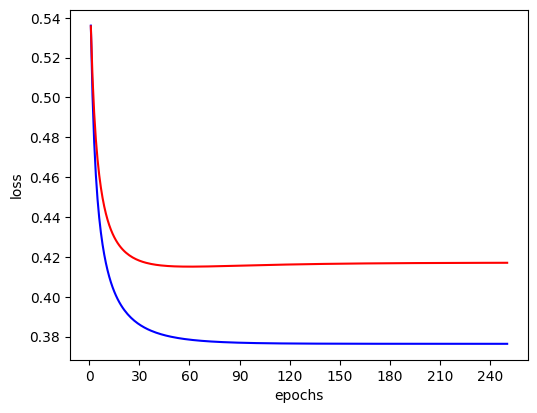

In [190]:
plt.figure(figsize=(13,10))
xticks = np.arange(num_step) + 1
plt.subplot(221)
plt.plot(xticks,train_losses,color = 'b', label = 'train loss')
plt.plot(xticks,test_losses, color = 'r', label = 'test loss')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer = True))
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

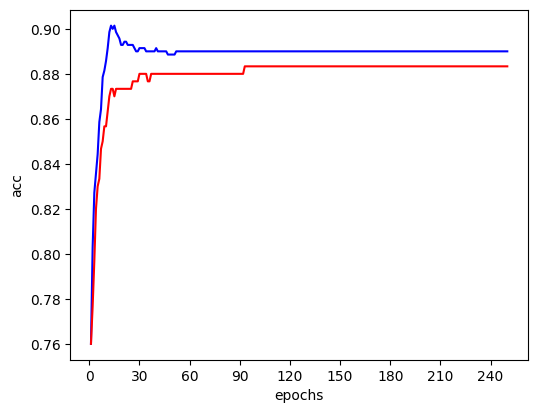

In [191]:
plt.figure(figsize=(13,10))
xticks = np.arange(num_step) + 1
plt.subplot(221)
plt.plot(xticks,train_acc,color = 'b', label = 'train loss')
plt.plot(xticks,test_acc, color = 'r', label = 'test loss')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer = True))
plt.xlabel('epochs')
plt.ylabel('acc')
plt.legend

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

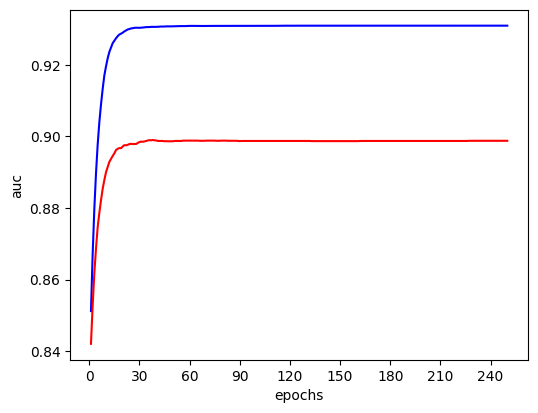

In [192]:
plt.figure(figsize=(13,10))
xticks = np.arange(num_step) + 1
plt.subplot(221)
plt.plot(xticks,train_auc,color = 'b', label = 'train loss')
plt.plot(xticks,test_auc, color = 'r', label = 'test loss')
plt.gca().xaxis.set_major_locator(MaxNLocator(integer = True))
plt.xlabel('epochs')
plt.ylabel('auc')
plt.legend

Text(0, 0.5, 'Y axis')

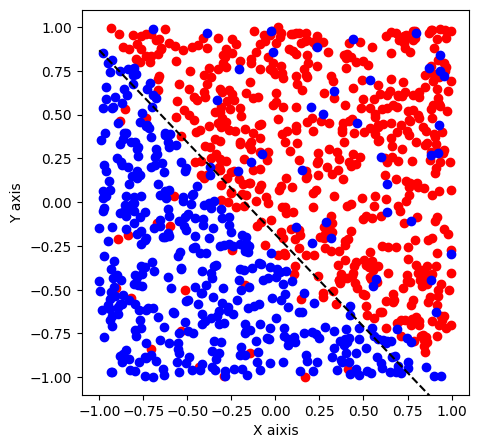

In [193]:
### 绘制模型学习到的曲线
plt.figure(figsize=(5,5))
plot_x = np.linspace(-1,1,100)
plot_y = -(theta[0] * plot_x  + theta[2]) / theta[1]
pos_index = np.where(y_total == 1)
neg_index = np.where(y_total == 0)
plt.scatter(x_total[pos_index, 0], x_total[pos_index, 1], c = 'r')
plt.scatter(x_total[neg_index, 0], x_total[neg_index, 1], c = 'b')
plt.plot(plot_x,plot_y,ls = '--', c = 'black')
plt.xlim(-1.1,1.1)
plt.ylim(-1.1,1.1)
plt.xlabel('X aixis')
plt.ylabel('Y axis')

# 使用sklearn进行逻辑回归

In [194]:
!pip install sklearn

You should consider upgrading via the '/Users/lixiansheng/Desktop/动手学机器学习/Hands-on-ML/第6章 逻辑斯谛回归/logisticvenv/bin/python3 -m pip install --upgrade pip' command.


In [195]:
from sklearn.linear_model import LogisticRegression
logs = LogisticRegression(solver='liblinear')
logs.fit(x_train, y_train)
logs.coef_, logs.intercept_
y_pred = logs.predict(x_test)
np.mean(y_pred == y_test)

np.float64(0.8833333333333333)

# 交叉熵与最大似然估计

## 什么是熵：
随机变量$X$熵的定义是$H(p) = \mathbb{E}_{X \sim p(x)}(- \log P(X)) = \sum -p(x_i) \log p(x_i)$